# SCD — LDA Flip: CS_sub7 → Medical_sub5
### CS 7180 · Aniket Ghosh · Spring 2026

**The bug in the previous run:** `h @ lda.scalings_` is wrong. sklearn's
`lda.transform(h)` does `(h - lda.xbar_) @ lda.scalings_` — subtracting the
training mean first. Without that centering every projected point lands in the
wrong place relative to the centroids, so the baseline was already 60% CS_sub0.

This version uses `lda.transform()` everywhere. The sanity check in cell 4
confirms the baseline is ~100% CS_sub7 before any patching.

**Three conditions measured:**
1. `lda_flip_n` — centroid direction CS_sub7 → Medical_sub5 (representational)
2. `ctrl_cs2_n` — centroid direction CS_sub7 → CS_sub2 (within-CS control)
3. `lm_diff_n` — output weight direction (our established causal direction)

**Two metrics per condition:**
- LDA nearest centroid: does the representation move to Medical_sub5 cluster?
- Output logit: does the CS → Medical prediction flip?

In [ ]:
!pip install transformers accelerate datasets scikit-learn pyarrow -q

In [ ]:
import os, pickle, json, torch, random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from google.colab import userdata

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

BASE_DIR   = '/content/drive/MyDrive/SCD_Final'
MODEL_ID   = 'meta-llama/Meta-Llama-3-8B-Instruct'
HF_TOKEN   = userdata.get('HF_TOKEN')
SEED       = 42
MAX_LEN    = 512
PC_LAYER   = 29
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
SUBCLASSES = ['CS_sub7', 'CS_sub2', 'CS_sub0', 'Medical_sub5']
LABEL_MAP  = {0:'CS',1:'Medical',2:'Civil',3:'ECE',4:'Psychology',5:'MAE',6:'Biochemistry'}
ALPHA_V    = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 40.0]

SUB_COLS = {'CS_sub7':'#4B9FFF','CS_sub2':'#00C880',
            'CS_sub0':'#FFB020','Medical_sub5':'#FF4D6A'}
BG, SURF, DIM = '#07111F', '#0D1E30', '#7A9AB8'

random.seed(SEED); np.random.seed(SEED)
for d in ['checkpoints','figures','results','data']:
    os.makedirs(f'{BASE_DIR}/{d}', exist_ok=True)
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


In [ ]:
# ── Load dataset ──────────────────────────────────────────────
train_path = f'{BASE_DIR}/data/wos_train.parquet'
test_path  = f'{BASE_DIR}/data/wos_test.parquet'
if os.path.exists(train_path):
    wos_train = pd.read_parquet(train_path)
    wos_test  = pd.read_parquet(test_path)
    print(f'Loaded: {len(wos_train)} train, {len(wos_test)} test')
else:
    from datasets import load_dataset
    ds = load_dataset('HDLTex/web_of_science', revision='refs/convert/parquet',
                      data_files={'train':'WOS46985/train/*.parquet'})
    full = ds['train'].to_pandas()
    full.rename(columns={'label_level_1':'level_1','label_level_2':'level_2','label':'level_3'},inplace=True)
    full['level_1'] = full['level_1'].map(LABEL_MAP)
    full['level_2'] = full['level_1'] + '_sub' + full['level_2'].astype(str)
    wos_train,wos_test = train_test_split(full,test_size=0.2,random_state=SEED,stratify=full['level_1'])
    wos_train.to_parquet(train_path); wos_test.to_parquet(test_path)
df_all = pd.concat([wos_train,wos_test]).reset_index(drop=True)

# ── Load model ────────────────────────────────────────────────
print(f'Loading {MODEL_ID}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map='auto',
    output_hidden_states=True, token=HF_TOKEN)
model.eval()
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

CS_ID  = tokenizer.encode(' CS',      add_special_tokens=False)[0]
MED_ID = tokenizer.encode(' Medical', add_special_tokens=False)[0]
W      = model.lm_head.weight.detach().float().cpu()
lm_diff_n = ((W[CS_ID]-W[MED_ID])/(W[CS_ID]-W[MED_ID]).norm()).numpy().astype(np.float32)
print(f'CS:{CS_ID}  Medical:{MED_ID}')

def make_prompt(doc):
    return (f'Document: {doc}\n\nThis document belongs to one of the following fields:\n'
            f'CS | Medical\n\nField:')

def extract_last_token(docs, layer=PC_LAYER, batch=8):
    vecs = []
    prompts = [make_prompt(d[:800]) for d in docs]
    for i in range(0,len(prompts),batch):
        bp = prompts[i:i+batch]
        enc = tokenizer(bp,return_tensors='pt',padding=True,truncation=True,max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad(): out = model(**enc, output_hidden_states=True)
        for b in range(len(bp)):
            last = int(enc['attention_mask'][b].sum())-1
            vecs.append(out.hidden_states[layer][b,last].float().cpu().numpy())
        del out,enc; torch.cuda.empty_cache()
        print(f'  [{i+len(bp)}/{len(prompts)}]',end='\r',flush=True)
    print()
    return np.stack(vecs).astype(np.float32)

Loaded: 37588 train, 9397 test
Loading meta-llama/Meta-Llama-3-8B-Instruct...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

VRAM: 16.1 GB
CS:10211  Medical:13235


In [ ]:
# ── Load activations ──────────────────────────────────────────
act_path = f'{BASE_DIR}/checkpoints/subclass_acts_L{PC_LAYER}.pkl'
if os.path.exists(act_path):
    print('Loading cached activations...')
    with open(act_path,'rb') as f: act_data = pickle.load(f)
else:
    act_data = {}
    for sub in SUBCLASSES:
        rows = df_all[df_all['level_2']==sub].sample(min(200,(df_all['level_2']==sub).sum()),random_state=SEED)
        print(f'{sub} ({len(rows)})...')
        act_data[sub] = {'acts':extract_last_token(rows['input_data'].tolist()),'docs':rows['input_data'].tolist()}
    with open(act_path,'wb') as f: pickle.dump(act_data,f)

all_acts     = np.vstack([act_data[s]['acts'] for s in SUBCLASSES])
all_labels_s = np.concatenate([[s]*len(act_data[s]['acts']) for s in SUBCLASSES])
for s in SUBCLASSES: print(f'  {s}: {act_data[s]["acts"].shape}')

Loading cached activations...
  CS_sub7: (200, 4096)
  CS_sub2: (200, 4096)
  CS_sub0: (200, 4096)
  Medical_sub5: (200, 4096)


In [ ]:
# ── Fit LDA + sanity check ────────────────────────────────────
le = LabelEncoder()
all_labels = le.fit_transform(all_labels_s)

lda   = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(all_acts, all_labels)   # uses lda.xbar_ internally

print(f'xbar_ shape: {lda.xbar_.shape}  <- mean subtracted in lda.transform()')
print('Explained discriminative variance:')
for i,v in enumerate(lda.explained_variance_ratio_):
    print(f'  Axis {i+1}: {v*100:.1f}%')

# Centroids in LDA space
centroids = {sub: X_lda[all_labels_s==sub].mean(0) for sub in SUBCLASSES}
centroid_matrix = np.stack([centroids[s] for s in SUBCLASSES])   # (4,3)

def nearest_sub(x_lda):
    return SUBCLASSES[np.argmin(np.linalg.norm(centroid_matrix - x_lda, axis=1))]

# ── SANITY CHECK — must be ~100% CS_sub7 at alpha=0 ──────────
# Use lda.transform(), not raw @ scalings_
X_lda_cs7 = lda.transform(act_data['CS_sub7']['acts'])   # (200,3) — correct centering
baseline   = [nearest_sub(x) for x in X_lda_cs7]
b_cs7      = sum(p=='CS_sub7' for p in baseline)/len(baseline)
print(f'\nSANITY CHECK — baseline CS_sub7 nearest centroid = CS_sub7: {b_cs7:.1%}')
print(Counter(baseline))
if b_cs7 < 0.8:
    print('WARNING: baseline is wrong — there may be a centering issue')
else:
    print('OK — baseline looks correct')

xbar_ shape: (4096,)  <- mean subtracted in lda.transform()
Explained discriminative variance:
  Axis 1: 74.1%
  Axis 2: 23.0%
  Axis 3: 2.9%

SANITY CHECK — baseline CS_sub7 nearest centroid = CS_sub7: 99.5%
Counter({'CS_sub7': 199, 'Medical_sub5': 1})
OK — baseline looks correct


In [ ]:
# ── Construct LDA flip direction ──────────────────────────────
# delta_lda  = c_target - c_source           (3,)    in LDA space
# delta_4096 = lda.scalings_ @ delta_lda     (4096,) back to activation space
# unit       = delta_4096 / ||delta_4096||   unit vector
#
# Direction construction uses scalings_ directly — correct here because
# we are constructing a DIRECTION VECTOR not projecting a POINT.
# Mean centering only matters when projecting points into LDA space.

def make_direction(source, target):
    delta_lda  = centroids[target] - centroids[source]
    delta_4096 = (lda.scalings_ @ delta_lda).astype(np.float32)
    unit       = delta_4096 / (np.linalg.norm(delta_4096)+1e-12)
    print(f'  {source} → {target}:')
    print(f'    LDA centroid distance:    {np.linalg.norm(delta_lda):.3f}')
    print(f'    Alignment with lm_diff_n: {abs(float(np.dot(unit,lm_diff_n))):.4f}')
    return unit

print('Directions:')
lda_flip_n = make_direction('CS_sub7','Medical_sub5')   # main
ctrl_cs2_n = make_direction('CS_sub7','CS_sub2')        # within-CS control

CONDITIONS = {
    'lda_flip (CS7→Med)': lda_flip_n,
    'control  (CS7→CS2)': ctrl_cs2_n,
    'lm_diff_n':           lm_diff_n,
}

Directions:
  CS_sub7 → Medical_sub5:
    LDA centroid distance:    21.489
    Alignment with lm_diff_n: 0.0232
  CS_sub7 → CS_sub2:
    LDA centroid distance:    34.439
    Alignment with lm_diff_n: 0.0044


In [ ]:
# ── Patch + re-project ────────────────────────────────────────
CACHE = f'{BASE_DIR}/checkpoints/lda_cs7_med_v4.pkl'

def patch_and_capture(prompt, direction_n, alpha):
    enc  = tokenizer(prompt,return_tensors='pt',truncation=True,max_length=MAX_LEN).to(DEVICE)
    d_t  = torch.tensor(direction_n,dtype=torch.float16,device=DEVICE)
    cap  = {}
    def hook(module,inp,out_t):
        hs   = out_t[0].clone() if isinstance(out_t,tuple) else out_t.clone()
        last = hs.shape[1]-1
        h    = hs[0,last].float()
        h    = h - float(alpha)*torch.dot(h,d_t.float())*d_t.float()
        hs[0,last] = h.half()
        cap['h'] = h.detach().cpu().numpy().astype(np.float32)
        return (hs,)+out_t[1:] if isinstance(out_t,tuple) else hs
    hk = model.model.layers[PC_LAYER-1].register_forward_hook(hook)
    with torch.no_grad(): out = model(**enc)
    hk.remove()
    lg = out.logits[0,-1].cpu().float().numpy()
    del out,enc; torch.cuda.empty_cache()
    return cap['h'], float(lg[CS_ID]), float(lg[MED_ID])

docs    = act_data['CS_sub7']['docs']
prompts = [make_prompt(d[:800]) for d in docs]

if os.path.exists(CACHE):
    print('Loading cached...')
    with open(CACHE,'rb') as f: results = pickle.load(f)
else:
    results = {cond:{a:[] for a in ALPHA_V} for cond in CONDITIONS}
    for idx,prompt in enumerate(prompts):
        print(f'  [{idx+1}/{len(prompts)}]',end='\r',flush=True)
        for cond,direction in CONDITIONS.items():
            for a in ALPHA_V:
                h_new,cs_lg,med_lg = patch_and_capture(prompt,direction,a)
                # CORRECT: use lda.transform() for proper centering
                x_lda = lda.transform(h_new.reshape(1,-1))[0]
                results[cond][a].append({
                    'lda_pred':  nearest_sub(x_lda),
                    'logit_flip':int(cs_lg < med_lg),
                    'd_med':     float(np.linalg.norm(x_lda-centroids['Medical_sub5'])),
                    'd_cs7':     float(np.linalg.norm(x_lda-centroids['CS_sub7'])),
                })
    print()
    with open(CACHE,'wb') as f: pickle.dump(results,f)
    print('Cached.')
print(f'{len(prompts)} examples done.')


Cached.
200 examples done.


In [ ]:
# ── Results ───────────────────────────────────────────────────
print('='*75)
print('  RESULTS — CS_sub7 examples (n=200)')
print('  LDA pred: nearest centroid after patching (lda.transform — correct)')
print('  Logit:    fraction where CS < Medical logit (output flip)')
print('='*75)

for cond in CONDITIONS:
    print(f'\n  {cond}')
    print(f'  {"alpha":>6}  {"→Medical":>10}  {"→CS_sub7":>10}  {"→CS_sub2":>10}  {"→CS_sub0":>10}  {"logit_flip":>12}')
    print('  '+'-'*68)
    for a in ALPHA_V:
        rows  = results[cond][a]
        preds = [r['lda_pred'] for r in rows]
        c     = Counter(preds)
        n     = len(rows)
        lf    = np.mean([r['logit_flip'] for r in rows])
        print(f'  {a:>6.1f}  '
              f'{c.get("Medical_sub5",0)/n:>10.3f}  '
              f'{c.get("CS_sub7",0)/n:>10.3f}  '
              f'{c.get("CS_sub2",0)/n:>10.3f}  '
              f'{c.get("CS_sub0",0)/n:>10.3f}  '
              f'{lf:>12.3f}')

print('\n'+'='*75)
print('SUMMARY at α=8:')
for cond in CONDITIONS:
    rows = results[cond][8.0]
    preds = [r['lda_pred'] for r in rows]
    f_med  = sum(p=='Medical_sub5' for p in preds)/len(preds)
    f_flip = np.mean([r['logit_flip'] for r in rows])
    print(f'  {cond:30s}: LDA→Medical={f_med:.1%}  logit_flip={f_flip:.1%}')

  RESULTS — CS_sub7 examples (n=200)
  LDA pred: nearest centroid after patching (lda.transform — correct)
  Logit:    fraction where CS < Medical logit (output flip)

  lda_flip (CS7→Med)
   alpha    →Medical    →CS_sub7    →CS_sub2    →CS_sub0    logit_flip
  --------------------------------------------------------------------
     0.0       0.215       0.520       0.155       0.110         0.050
     0.5       0.045       0.765       0.170       0.020         0.050
     1.0       0.000       0.790       0.210       0.000         0.050
     2.0       0.020       0.555       0.410       0.015         0.050
     3.0       0.045       0.360       0.555       0.040         0.050
     5.0       0.035       0.105       0.765       0.095         0.050
     8.0       0.015       0.055       0.800       0.130         0.050
    12.0       0.025       0.030       0.810       0.135         0.050
    20.0       0.005       0.010       0.825       0.160         0.050
    40.0       0.000       0.0

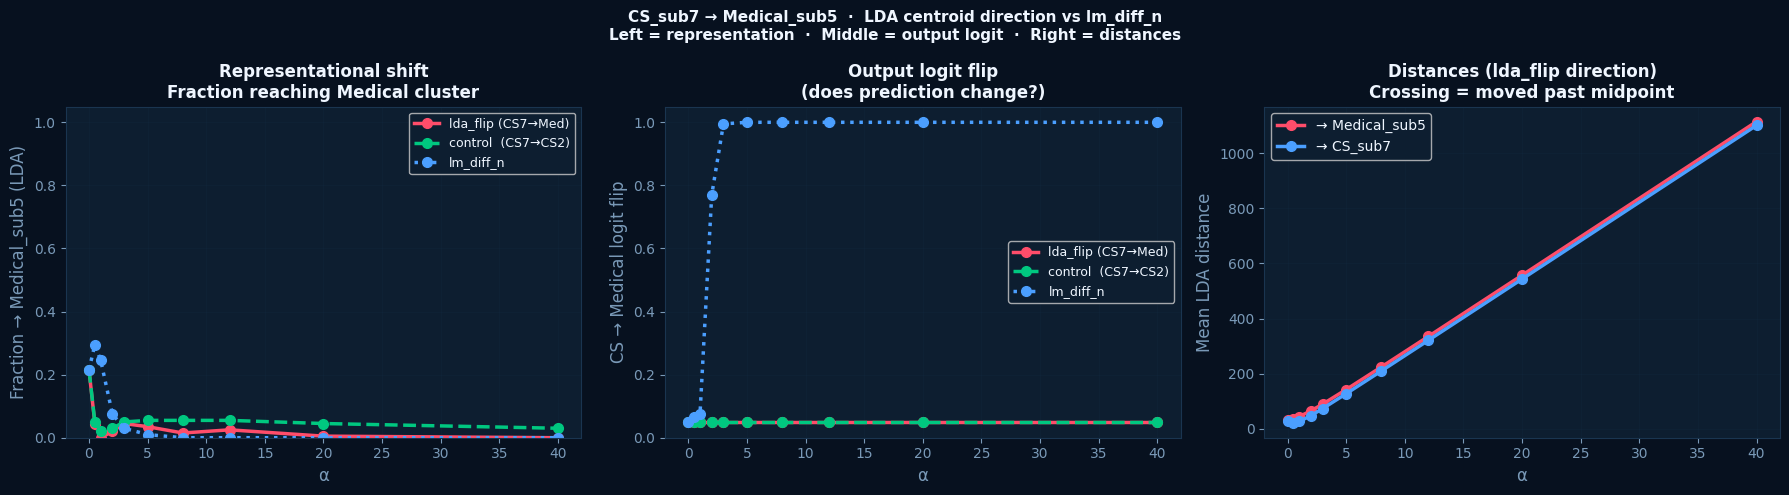

Saved.


In [ ]:
# ── Plot ──────────────────────────────────────────────────────
COND_COLS = {'lda_flip (CS7→Med)':'#FF4D6A',
             'control  (CS7→CS2)':'#00C880',
             'lm_diff_n':          '#4B9FFF'}
COND_LS   = {'lda_flip (CS7→Med)':'-','control  (CS7→CS2)':'--','lm_diff_n':':'}

fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(18,5))
fig.patch.set_facecolor(BG)
for ax in (ax1,ax2,ax3):
    ax.set_facecolor(SURF); ax.tick_params(colors=DIM)
    ax.xaxis.label.set_color(DIM); ax.yaxis.label.set_color(DIM)
    ax.title.set_color('#EFF6FF')
    for sp in ax.spines.values(): sp.set_edgecolor('#1A3550')

# LDA nearest centroid → Medical
for cond in CONDITIONS:
    fracs = [sum(r['lda_pred']=='Medical_sub5' for r in results[cond][a])/len(results[cond][a])
             for a in ALPHA_V]
    ax1.plot(ALPHA_V,fracs,COND_LS[cond]+'o',color=COND_COLS[cond],
             linewidth=2.5,markersize=7,label=cond)
ax1.set_xlabel('α',fontsize=12); ax1.set_ylabel('Fraction → Medical_sub5 (LDA)',fontsize=12)
ax1.set_title('Representational shift\nFraction reaching Medical cluster',fontweight='bold')
ax1.legend(fontsize=9,facecolor=SURF,labelcolor='#EFF6FF')
ax1.set_ylim(0,1.05); ax1.grid(alpha=0.15,color='#1A3550')

# Output logit flip
for cond in CONDITIONS:
    fracs = [np.mean([r['logit_flip'] for r in results[cond][a]]) for a in ALPHA_V]
    ax2.plot(ALPHA_V,fracs,COND_LS[cond]+'o',color=COND_COLS[cond],
             linewidth=2.5,markersize=7,label=cond)
ax2.set_xlabel('α',fontsize=12); ax2.set_ylabel('CS → Medical logit flip',fontsize=12)
ax2.set_title('Output logit flip\n(does prediction change?)',fontweight='bold')
ax2.legend(fontsize=9,facecolor=SURF,labelcolor='#EFF6FF')
ax2.set_ylim(0,1.05); ax2.grid(alpha=0.15,color='#1A3550')

# Distance trajectory — lda_flip only
cond_main = 'lda_flip (CS7→Med)'
d_med = [np.mean([r['d_med'] for r in results[cond_main][a]]) for a in ALPHA_V]
d_cs7 = [np.mean([r['d_cs7'] for r in results[cond_main][a]]) for a in ALPHA_V]
ax3.plot(ALPHA_V,d_med,'o-',color='#FF4D6A',linewidth=2.5,markersize=7,label='→ Medical_sub5')
ax3.plot(ALPHA_V,d_cs7,'o-',color='#4B9FFF',linewidth=2.5,markersize=7,label='→ CS_sub7')
ax3.set_xlabel('α',fontsize=12); ax3.set_ylabel('Mean LDA distance',fontsize=12)
ax3.set_title('Distances (lda_flip direction)\nCrossing = moved past midpoint',fontweight='bold')
ax3.legend(fontsize=10,facecolor=SURF,labelcolor='#EFF6FF')
ax3.grid(alpha=0.15,color='#1A3550')

plt.suptitle('CS_sub7 → Medical_sub5  ·  LDA centroid direction vs lm_diff_n\n'
             'Left = representation  ·  Middle = output logit  ·  Right = distances',
             fontweight='bold',color='#EFF6FF',fontsize=11)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/lda_cs7_to_medical.png',dpi=150,facecolor=BG,bbox_inches='tight')
plt.show()

out = {cond:{str(a):{
    'medical_frac': sum(r['lda_pred']=='Medical_sub5' for r in results[cond][a])/len(results[cond][a]),
    'cs7_frac':     sum(r['lda_pred']=='CS_sub7' for r in results[cond][a])/len(results[cond][a]),
    'logit_flip':   float(np.mean([r['logit_flip'] for r in results[cond][a]])),
} for a in ALPHA_V} for cond in results}
with open(f'{BASE_DIR}/results/lda_cs7_to_medical.json','w') as f: json.dump(out,f,indent=2)
print('Saved.')